<a href="https://colab.research.google.com/github/Kabshah/Assignments-Genie/blob/main/ANN_Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
iris = load_iris()

X = iris.data[:, :3]   # only first 3 features
y = iris.target

In [3]:
df = pd.DataFrame(X)

# Check missing values
print(df.isnull().sum())

# Fill missing values if any
df = df.fillna(df.mean())

X = df.values

0    0
1    0
2    0
dtype: int64


In [6]:
encoder = LabelEncoder()
y = encoder.fit_transform(y)
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
model = Sequential()

model.add(Dense(8, activation='relu', input_shape=(3,)))
model.add(Dense(8, activation='relu'))
model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3542 - loss: 1.2182 - val_accuracy: 0.2917 - val_loss: 1.2404
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3542 - loss: 1.1832 - val_accuracy: 0.2917 - val_loss: 1.2064
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3542 - loss: 1.1465 - val_accuracy: 0.2917 - val_loss: 1.1781
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3542 - loss: 1.1132 - val_accuracy: 0.2917 - val_loss: 1.1522
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3854 - loss: 1.0839 - val_accuracy: 0.4167 - val_loss: 1.1254
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7188 - loss: 1.0537 - val_accuracy: 0.5000 - val_loss: 1.1013
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7188 - loss: 1.0232 - val_accuracy: 0.5000 - val_loss: 1.0766
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7188 - loss: 0.9953 - val_accuracy: 0.5000 - val_los

In [10]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step - accuracy: 0.9333 - loss: 0.2779
Accuracy: 0.9333333373069763


In [11]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

print(classification_report(y_test, y_pred_classes))
print(confusion_matrix(y_test, y_pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.89      0.89      0.89         9
           2       0.91      0.91      0.91        11

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

[[10  0  0]
 [ 0  8  1]
 [ 0  1 10]]


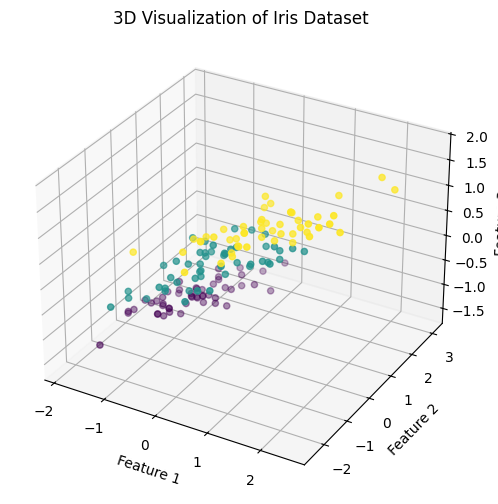

In [12]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X[:,0],
    X[:,1],
    X[:,2],
    c=y,
    cmap='viridis'
)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Feature 3')

plt.title("3D Visualization of Iris Dataset")

plt.show()